# Data distribution experiments and understanding

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import gsw
import numpy as np
from mpl_toolkits.basemap import Basemap

In [9]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]

# Calculate density based on temperature, salinity, latitude and depth
df_ST['Pressure_[dbar]'] = gsw.p_from_z(-df_ST['Depth_[m]'].values, df_ST['Latitude_[deg_N]'].values)
df_ST['Density_[kg_per_m^3]'] = gsw.density.rho(df_ST['Absolute_Salinity_[PSU]'].values, df_ST['Conservative_Temperature_[deg_C]'].values, df_ST['Pressure_[dbar]'])
df_ST['Spice'] = gsw.spiciness0(df_ST['Absolute_Salinity_[PSU]'], df_ST['Conservative_Temperature_[deg_C]'])

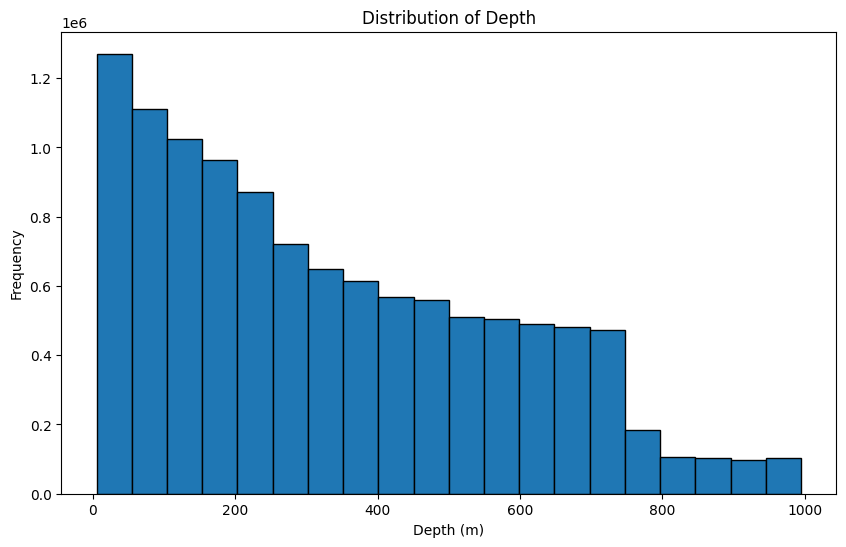

In [3]:
# Data distribution in depth
plt.figure(figsize=(10, 6))
plt.hist(df_ST['Depth_[m]'], bins=20, edgecolor='black')
plt.title('Distribution of Depth')
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.show()

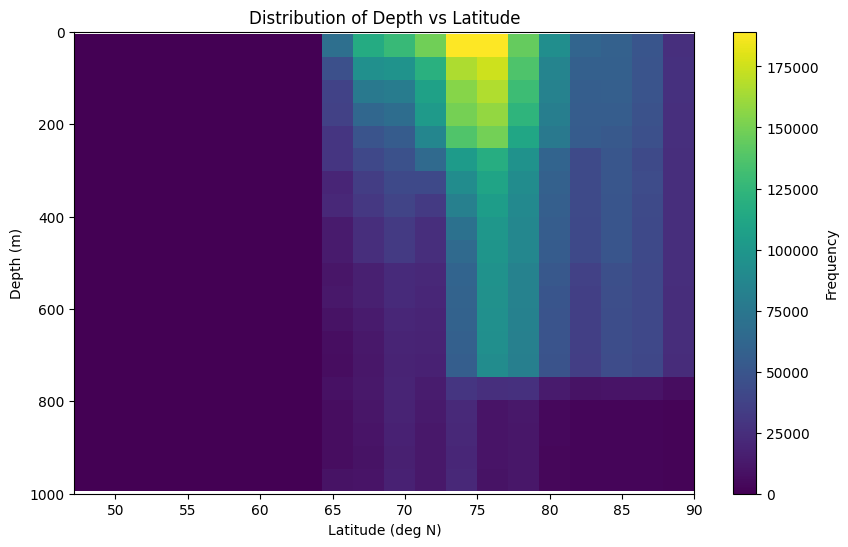

In [4]:
# Data distribution geographically in depth (how many depths per latitude bin)
plt.figure(figsize=(10, 6))
plt.hist2d(df_ST['Latitude_[deg_N]'], df_ST['Depth_[m]'], bins=[20, 20], cmap='viridis')
plt.colorbar(label='Frequency')
plt.ylim(1000,0)
plt.title('Distribution of Depth vs Latitude')
plt.ylabel('Depth (m)')
plt.xlabel('Latitude (deg N)')
plt.show()

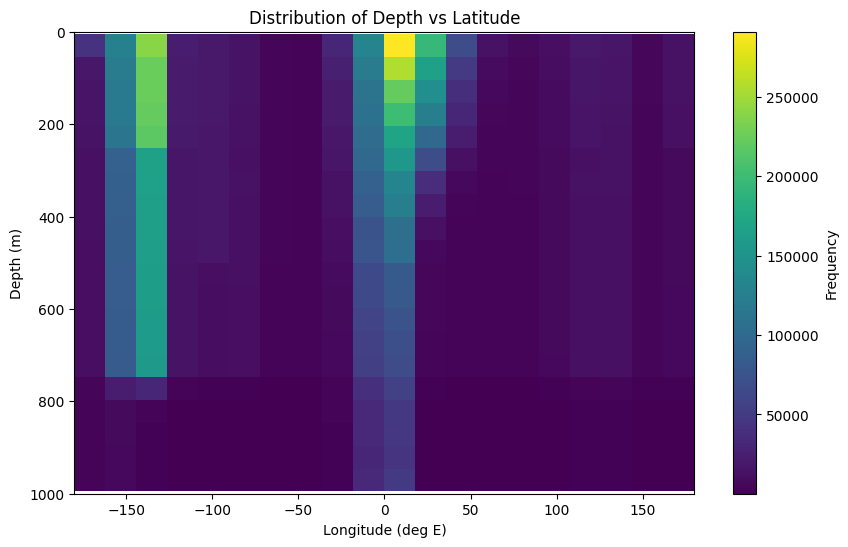

In [5]:
# Data distribution geographically in depth (how many depths per longitude bin)
plt.figure(figsize=(10, 6))
plt.hist2d(df_ST['Longitude_[deg_E]'], df_ST['Depth_[m]'], bins=[20, 20], cmap='viridis')
plt.colorbar(label='Frequency')
plt.ylim(1000,0)
plt.title('Distribution of Depth vs Latitude')
plt.ylabel('Depth (m)')
plt.xlabel('Longitude (deg E)')
plt.show()

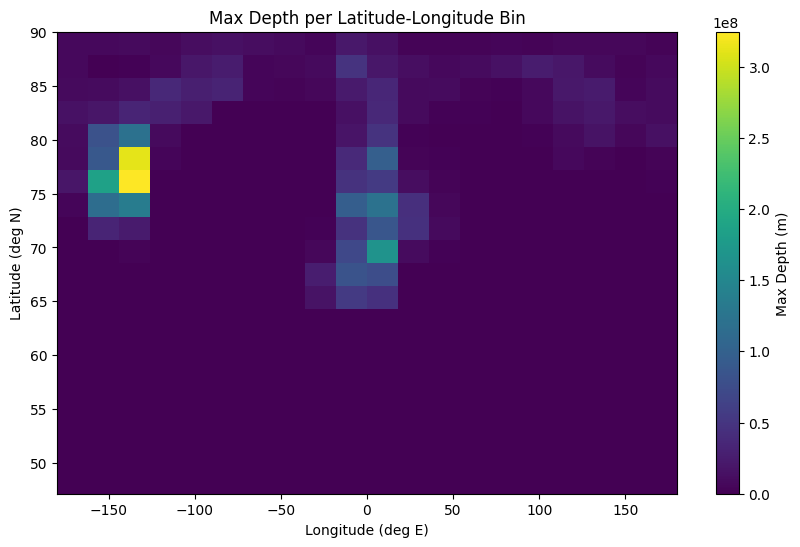

In [6]:
# Plot of max depth per latitude longitude bin
plt.figure(figsize=(10, 6))
plt.hist2d(df_ST['Longitude_[deg_E]'], df_ST['Latitude_[deg_N]'], bins=[20, 20], cmap='viridis', weights=df_ST['Depth_[m]'])
plt.colorbar(label='Max Depth (m)')
plt.title('Max Depth per Latitude-Longitude Bin')
plt.xlabel('Longitude (deg E)')
plt.ylabel('Latitude (deg N)')
plt.show()

In [7]:
def plot_heatmap(ds_cleaned, bin_max=None):
    '''
    ds_cleaned: A dataset containing cleaned data.
    bin_max (optional): The maximum bin value for the heatmap. If not provided, it is calculated as the maximum value of the histogram.
    '''
    # Define the map bounds and resolution
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90
    latlon_step = 5
    resolution = 'l'  # l for low resolution, h for high resolution

    # Define bin edges for longitude, latitude, and pressure
    lon_bins = np.arange(lon_min, lon_max+1, latlon_step)
    lat_bins = np.arange(lat_min, lat_max+1, latlon_step)

    # Compute max depth per bin instead of profile count
    n_lon = len(lon_bins) - 1
    n_lat = len(lat_bins) - 1
    H = np.zeros((n_lon, n_lat))

    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values
    depth_vals = ds_cleaned['Depth_[m]'].values  # adjust column name if needed

    lon_idx = np.digitize(lon_vals, lon_bins) - 1
    lat_idx = np.digitize(lat_vals, lat_bins) - 1

    for i in range(len(lon_vals)):
        li, lj = lon_idx[i], lat_idx[i]
        if 0 <= li < n_lon and 0 <= lj < n_lat:
            if depth_vals[i] > H[li, lj]:
                H[li, lj] = depth_vals[i]

    # Set up the figure and the Basemap instance
    fig = plt.figure(figsize=(8,8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)
    m.drawparallels(np.arange(lat_min, lat_max+1, 5), labels=[], linewidth=0.1)
    m.drawmeridians(np.arange(lon_min, lon_max+1, 5), labels=[], linewidth=0.1)

    # Create the X and Y grids for the histogram
    X, Y = np.meshgrid(lon_bins[:-1], lat_bins[:-1])

    new_col = np.arange(lat_min, lat_max, latlon_step)
    Y = np.concatenate((Y, new_col[:, np.newaxis]), axis=1)
    new_col = lon_max * np.ones(len(lat_bins) - 1)
    X = np.concatenate((X, new_col[:, np.newaxis]), axis=1)
    new_row = X[-1]
    X = np.vstack([X, new_row])
    new_row = lat_max * np.ones(np.shape(Y)[1])
    Y = np.vstack([Y, new_row])

    # Create the colored grid using pcolormesh
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max, latlon=True)
    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    # Add a colorbar
    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Max Depth [m]')

    # Set the axis labels and title
    plt.xticks([])
    plt.yticks([])
    plt.title('Max Depth per Bin')

    # Show the plot
    plt.show()
    print(f'bin max={bin_max}')

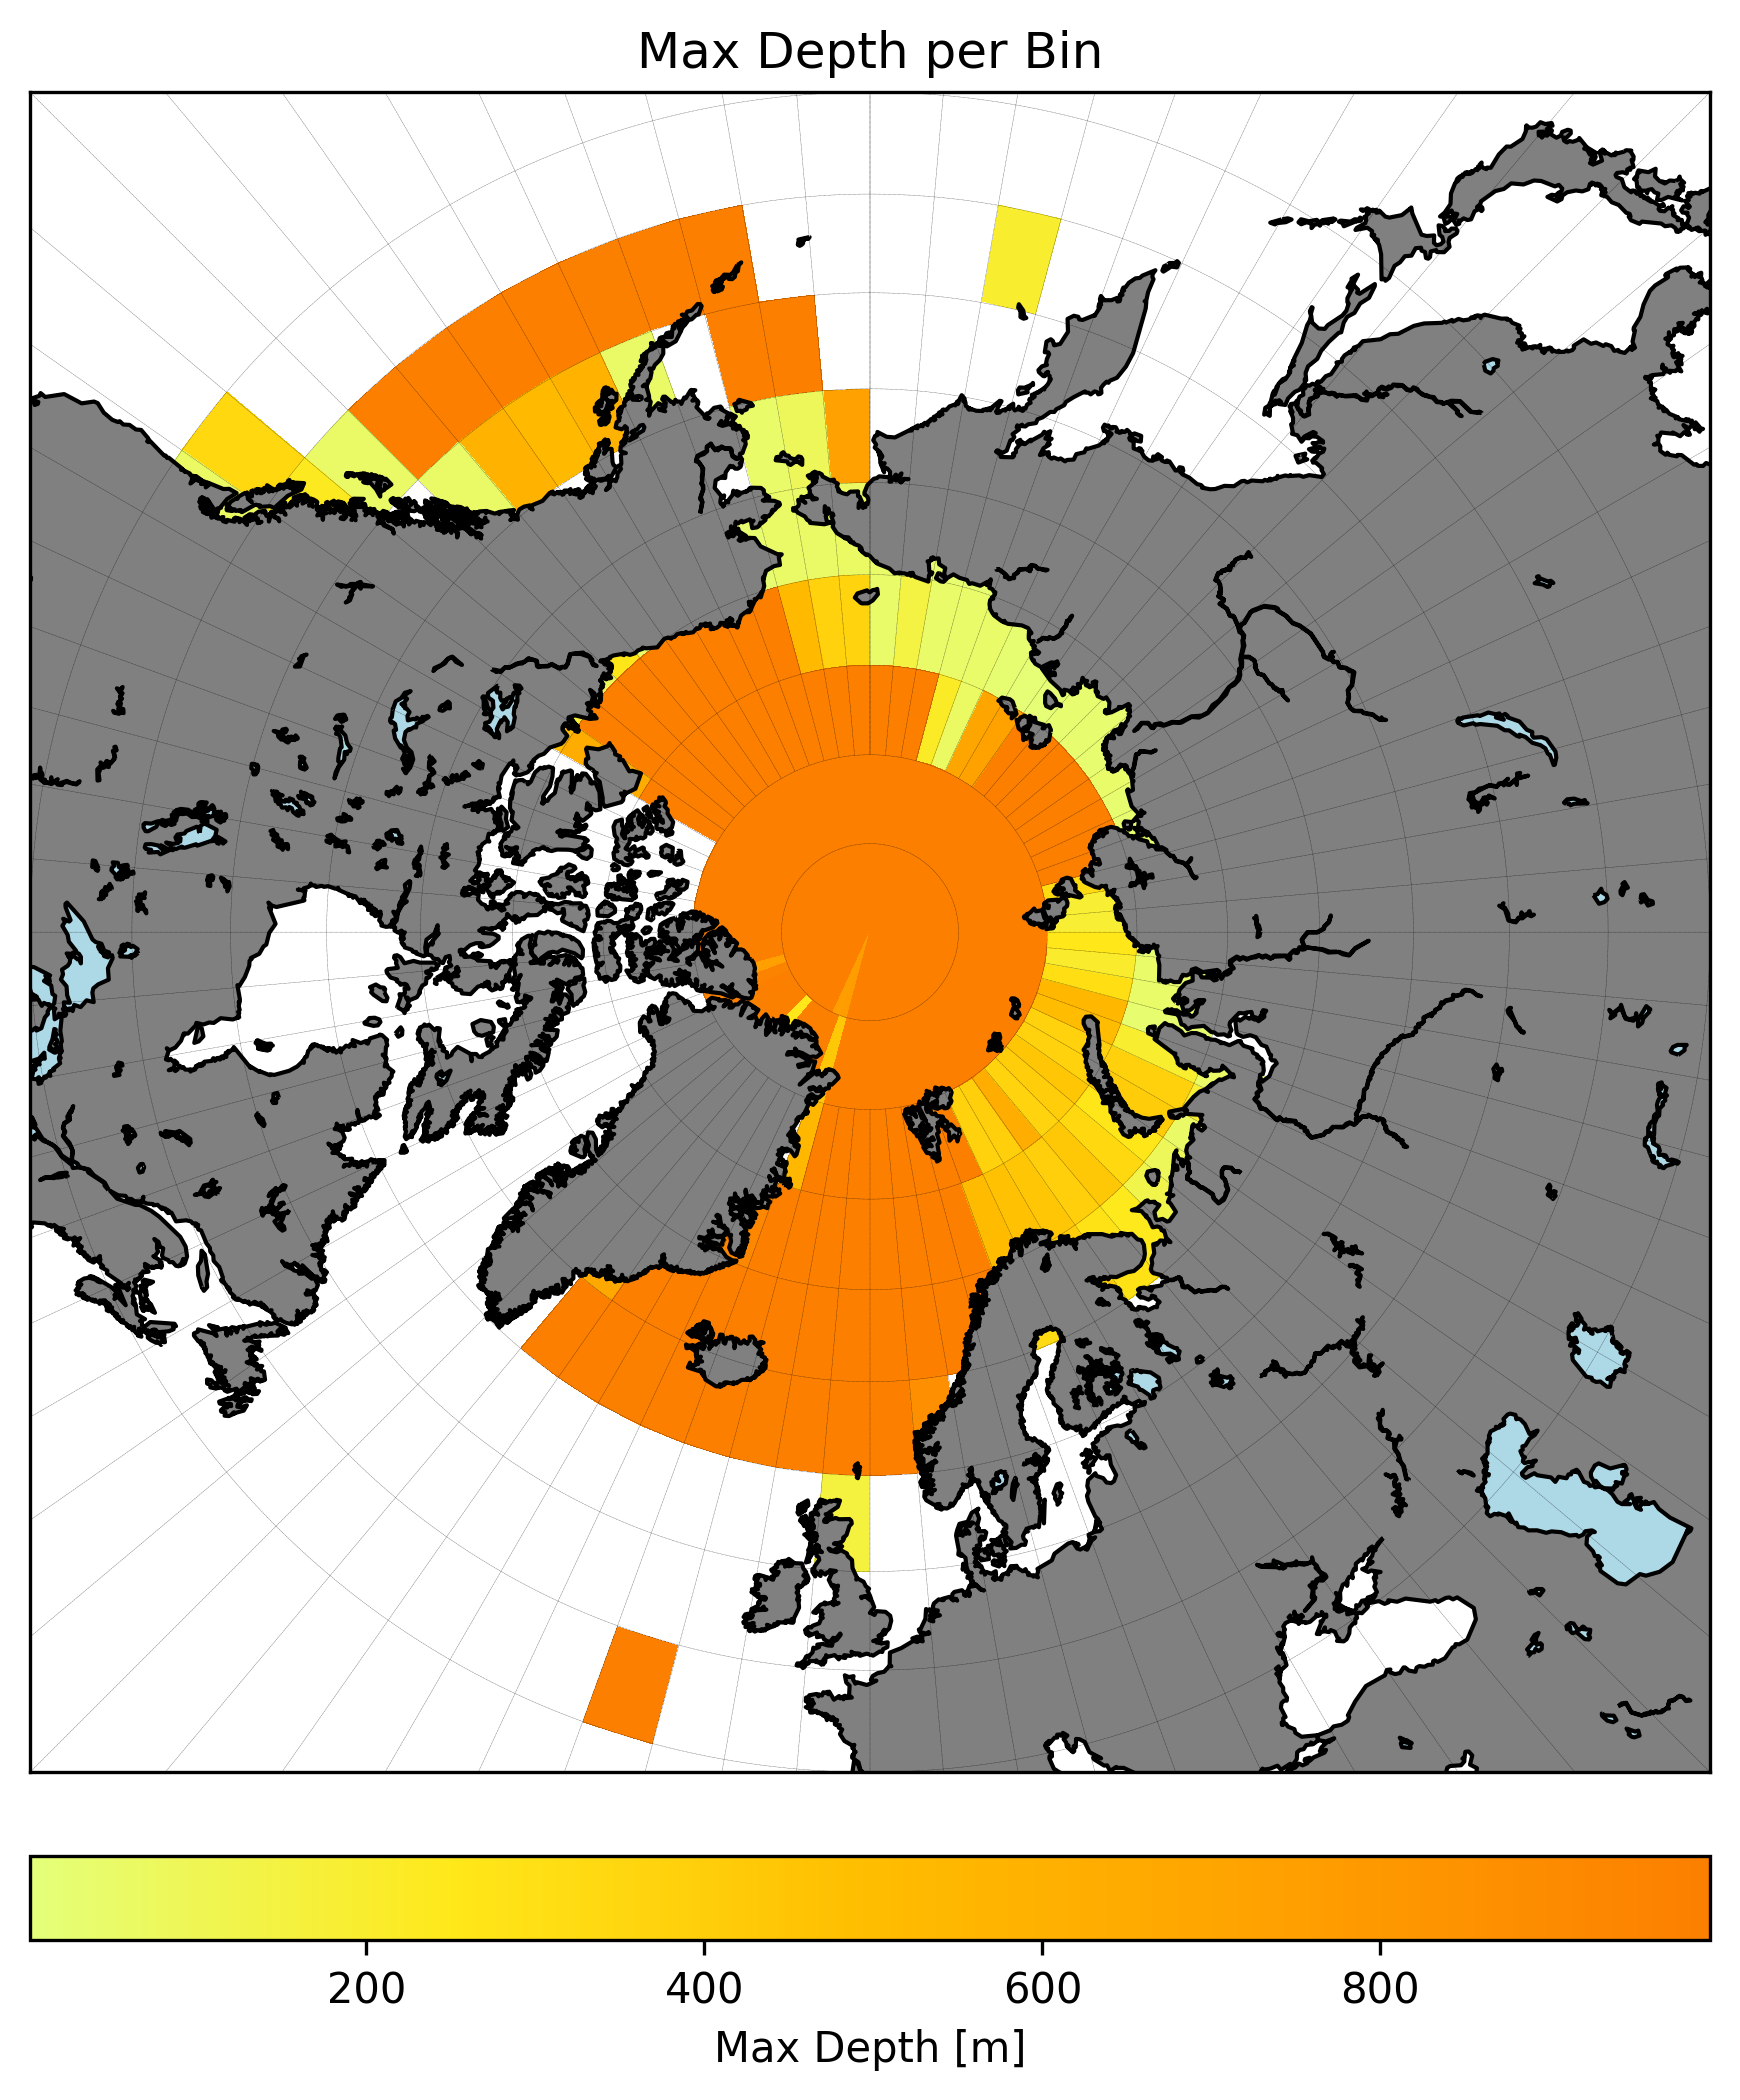

bin max=995.0


In [8]:
plot_heatmap(df_ST)

In [16]:
def plot_heatmap(ds_cleaned, n_lon_bins=72, n_lat_bins=9, bin_max=None):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90
    resolution = 'l'

    # Equal-area bins: uniform in longitude, uniform in sin(latitude)
    lon_bins = np.linspace(lon_min, lon_max, n_lon_bins + 1)
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.linspace(sin_min, sin_max, n_lat_bins + 1)
    lat_bins = np.degrees(np.arcsin(sin_bins))

    # Compute max depth per bin
    n_lon = len(lon_bins) - 1
    n_lat = len(lat_bins) - 1
    H = np.zeros((n_lon, n_lat))

    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values
    depth_vals = ds_cleaned['Depth_[m]'].values

    lon_idx = np.digitize(lon_vals, lon_bins) - 1
    lat_idx = np.digitize(lat_vals, lat_bins) - 1

    for i in range(len(lon_vals)):
        li, lj = lon_idx[i], lat_idx[i]
        if 0 <= li < n_lon and 0 <= lj < n_lat:
            if depth_vals[i] > H[li, lj]:
                H[li, lj] = depth_vals[i]

    fig = plt.figure(figsize=(8,8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)

    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    # Draw sine-lat bin edges as lightgrey lines
    # Latitude lines (at each lat_bins edge)
    for lat in lat_bins:
        lons = np.linspace(lon_min, lon_max, 500)
        lats = np.full_like(lons, lat)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Longitude lines (at each lon_bins edge)
    for lon in lon_bins:
        lats = np.linspace(lat_min, lat_max, 500)
        lons = np.full_like(lats, lon)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    # Plot data on top
    X, Y = np.meshgrid(lon_bins, lat_bins)
    X_map, Y_map = m(X, Y)

    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    m.pcolormesh(X_map, Y_map, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Redraw coastlines on top of pcolormesh
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Max Depth [m]')

    plt.xticks([])
    plt.yticks([])
    plt.title('Max Depth per Bin')

    plt.show()
    print(f'bin max={bin_max}')

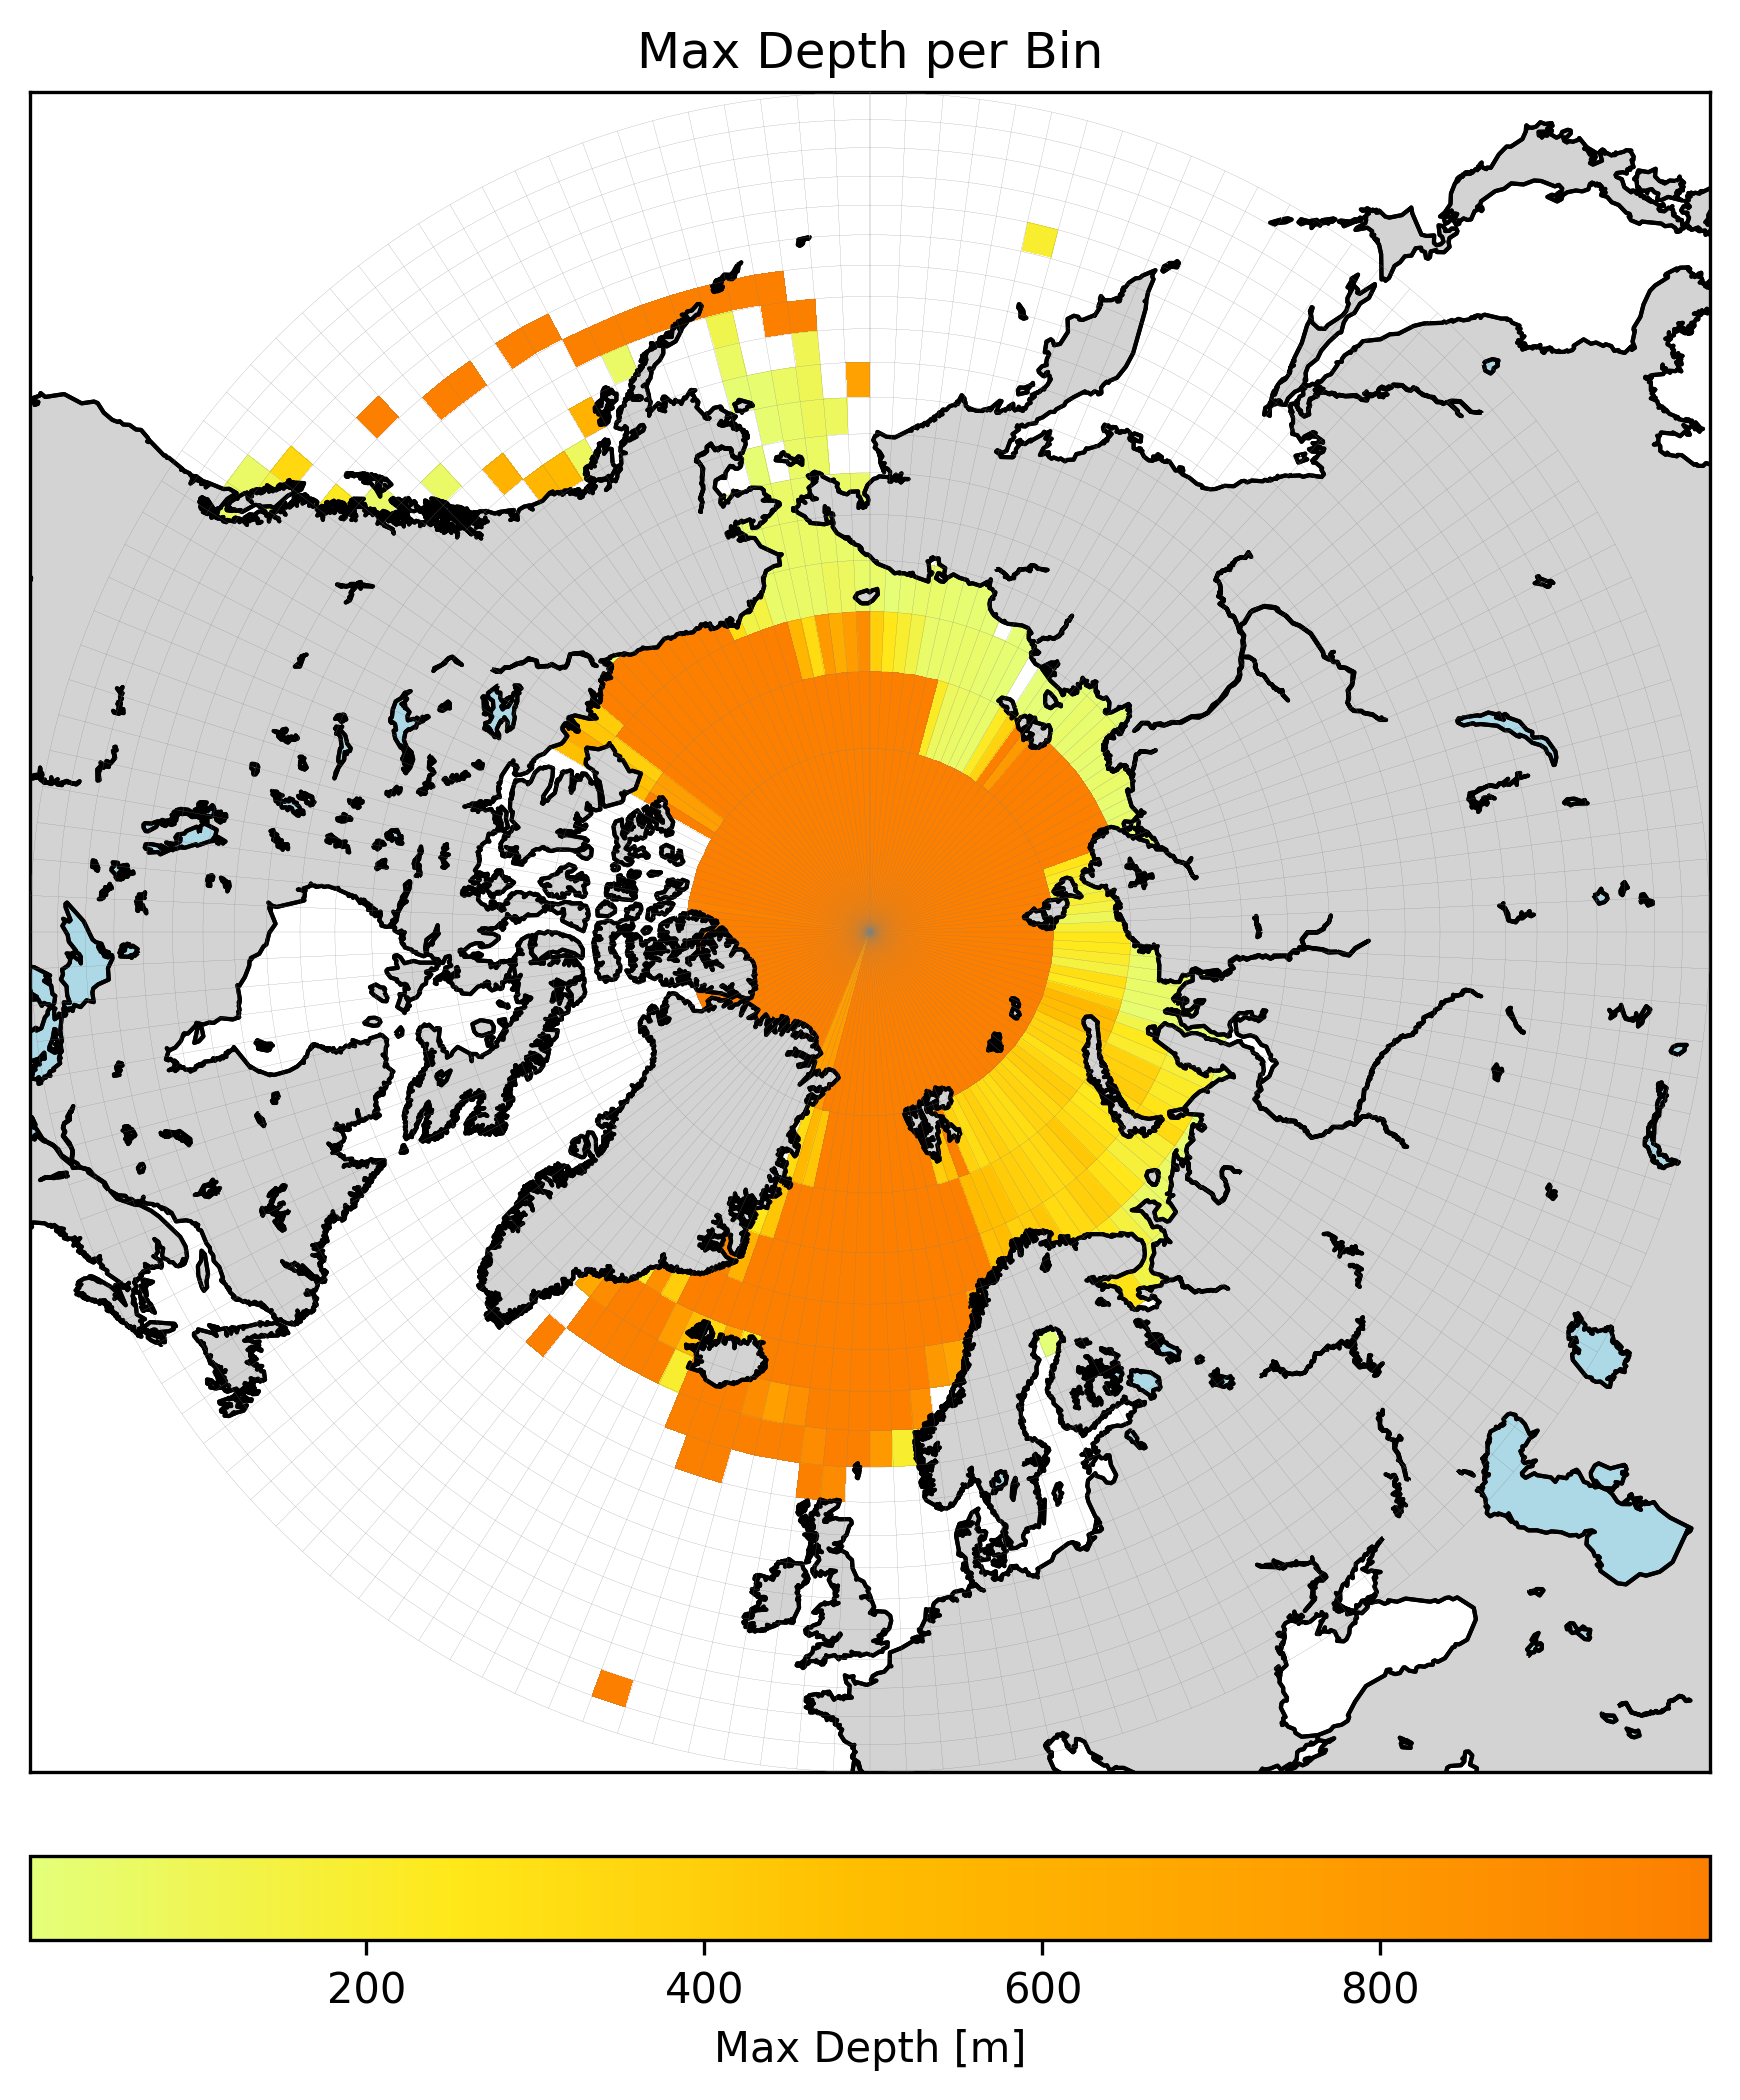

bin max=995.0


In [10]:
plot_heatmap(df_ST,n_lon_bins=144, n_lat_bins=18)

In [33]:
from pyproj import Transformer
import rasterio
import numpy as np

with rasterio.open('../../../ibcao_v5_1_2025_depth_400m.tif') as src:
    data = src.read()  # shape: (n_bands, rows, cols)
    transform = src.transform
    crs = src.crs

rows, cols = np.meshgrid(np.arange(data.shape[1]), np.arange(data.shape[2]), indexing='ij')
xs, ys = rasterio.transform.xy(transform, rows.flatten(), cols.flatten())

# Reproject from native CRS to WGS84 lon/lat
transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
lons, lats = transformer.transform(xs, ys)

df_topo = pd.DataFrame({
    'Longitude_[deg_E]': lons,
    'Latitude_[deg_N]': lats,
    'Depth_[m]': -data[0].flatten()  # IBCAO stores depth as negative, flip sign
})

# Drop nodata
nodata = -9999  # typical IBCAO nodata value
df_topo = df_topo[df_topo['Depth_[m]'] != -nodata]
df_topo = df_topo[df_topo['Depth_[m]'] > 0]  # keep ocean depths only
df_topo[df_topo['Depth_[m]'] <= 0.01] = 0.01  # set very shallow depths to a small positive value for log scaling

In [34]:
df_topo.describe()

,Longitude_[deg_E],Latitude_[deg_N],Depth_[m]
count,1.055607e+08,1.055607e+08,1.055607e+08
mean,-1.361462e+01,7.339670e+01,1.305533e+03
std,9.903348e+01,7.565939e+00,1.400444e+03
min,-1.799961e+02,1.000000e-02,1.000000e-02
25%,-8.849896e+01,6.861831e+01,1.026793e+02
50%,-1.734494e+01,7.381440e+01,4.311091e+02
75%,5.398478e+01,7.880138e+01,2.635484e+03
max,1.799961e+02,8.999742e+01,5.559280e+03


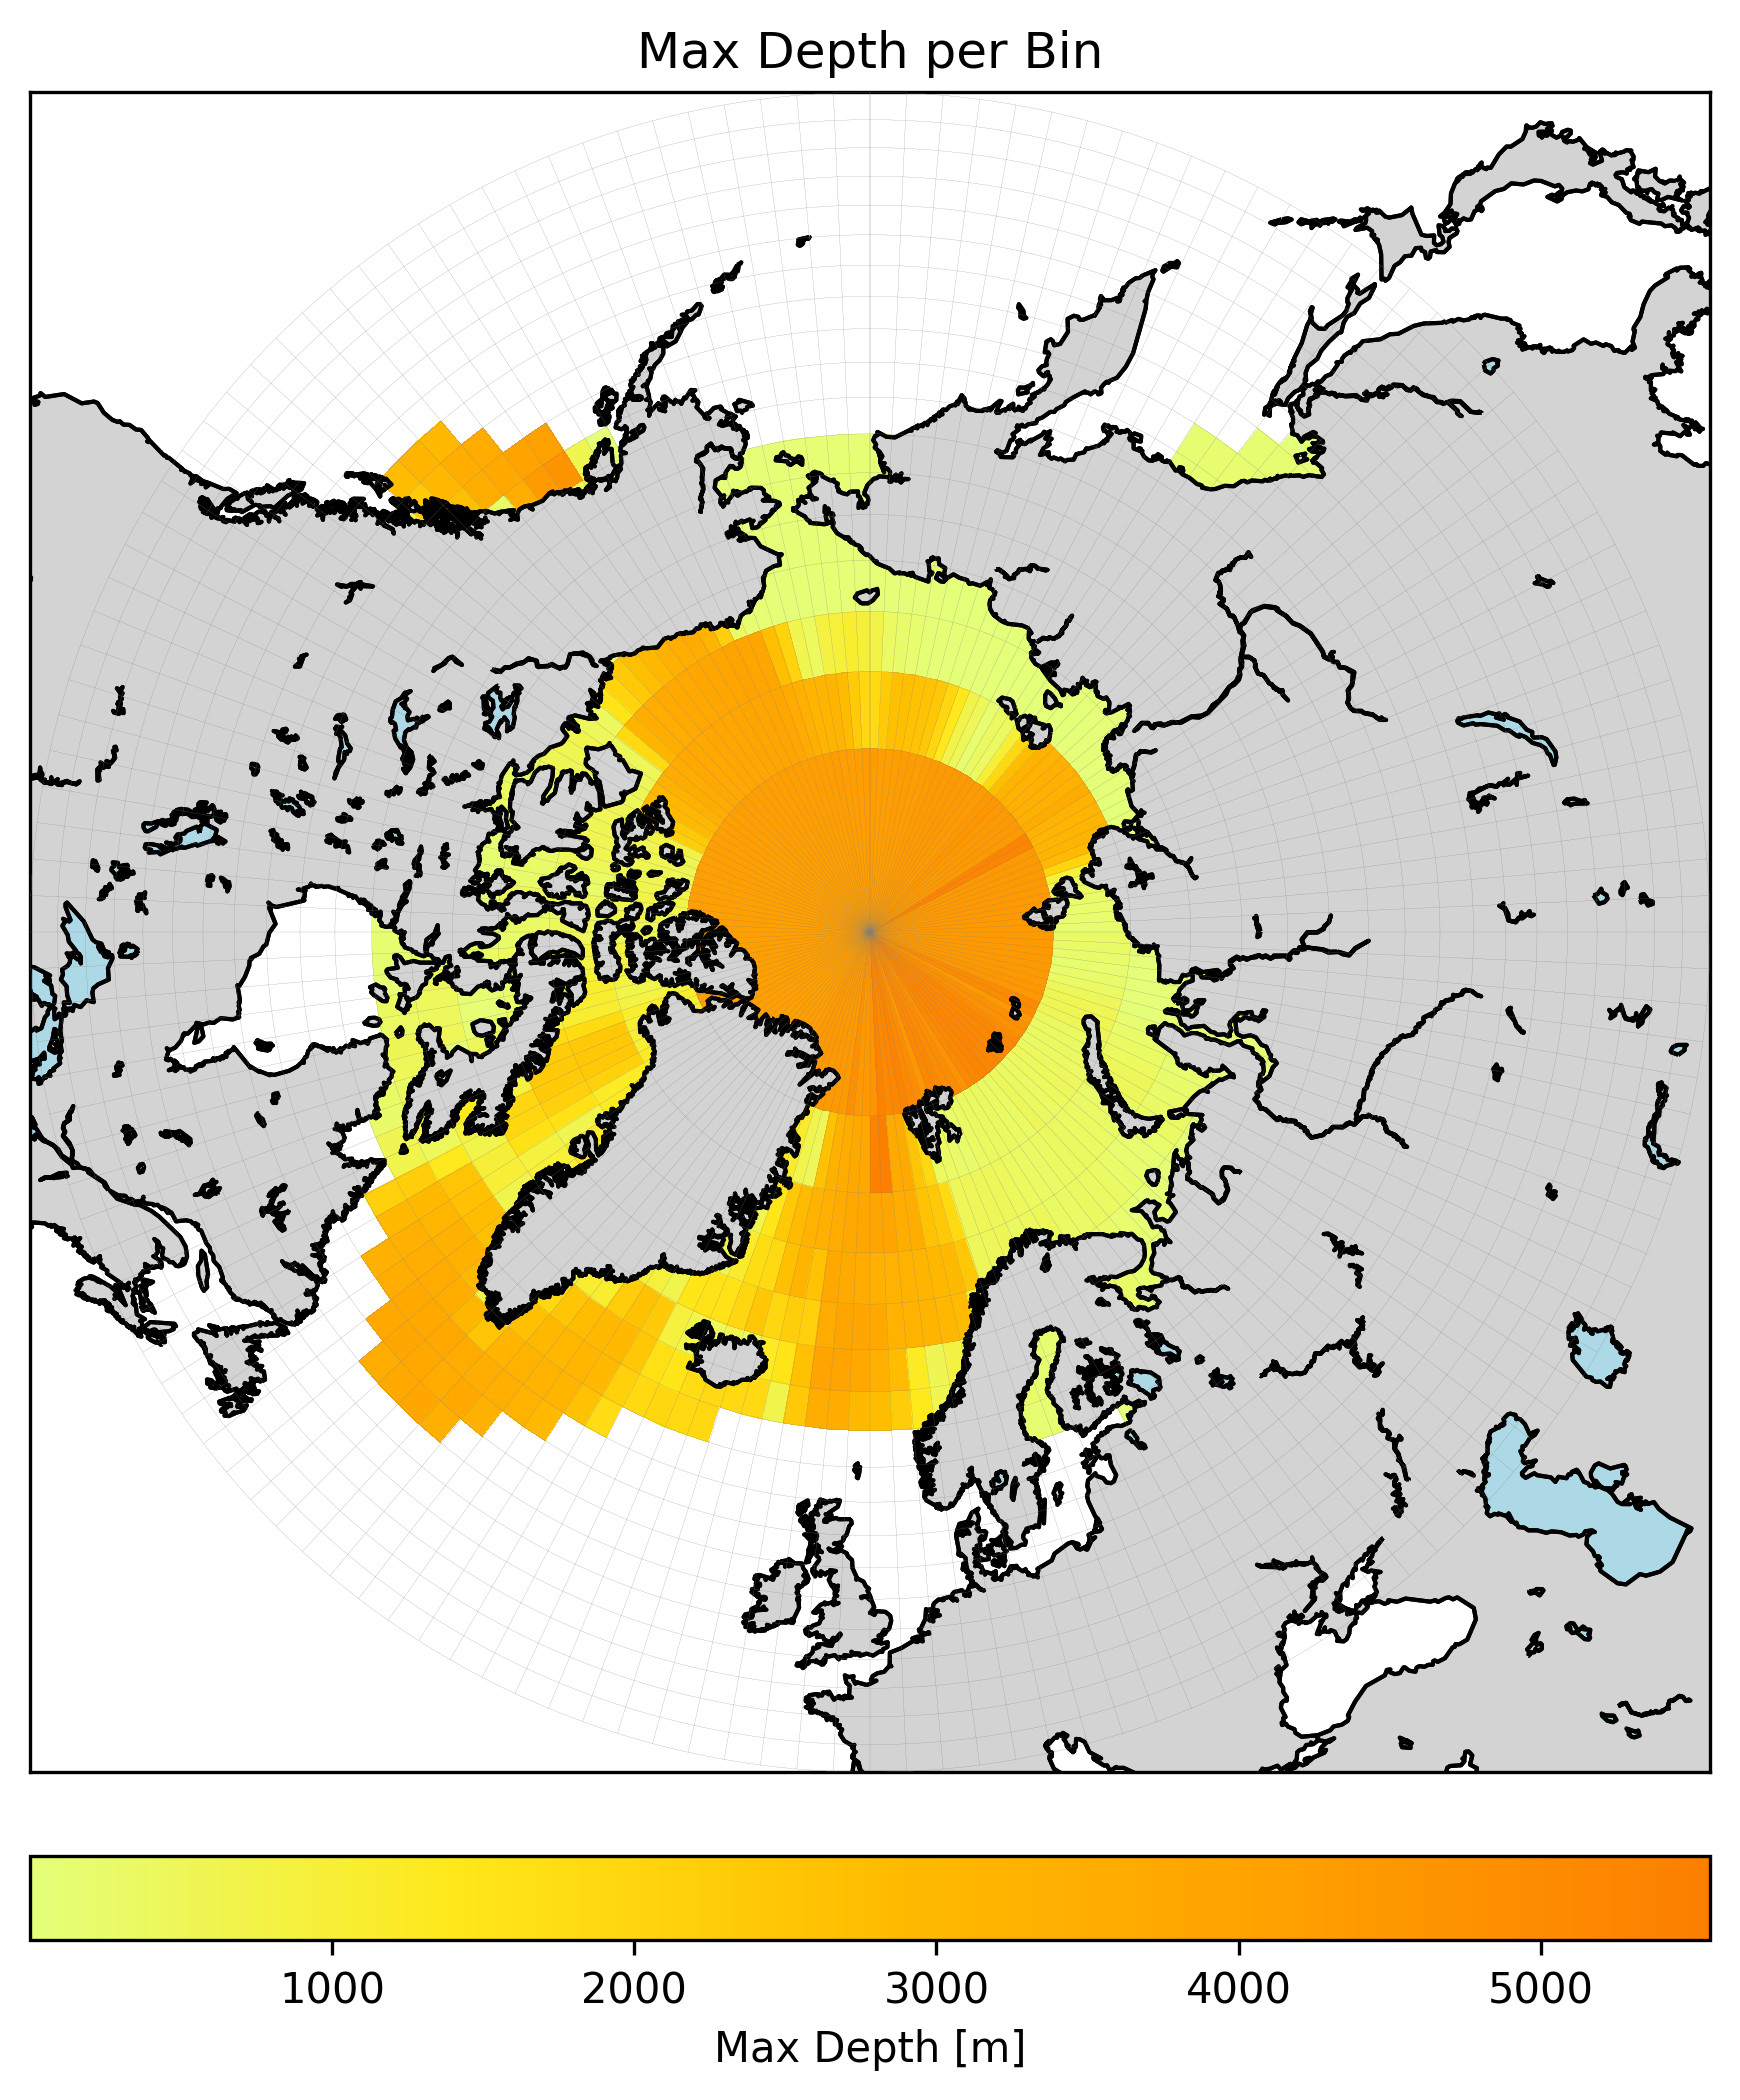

bin max=5559.2802734375


In [35]:
plot_heatmap(df_topo,n_lon_bins=144, n_lat_bins=18)

In [10]:
def plot_depthindex(ds_cleaned, ds_topo, n_lon_bins=72, n_lat_bins=9):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90
    resolution = 'l'

    # Equal-area bins
    lon_bins = np.linspace(lon_min, lon_max, n_lon_bins + 1)
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.linspace(sin_min, sin_max, n_lat_bins + 1)
    lat_bins = np.degrees(np.arcsin(sin_bins))
    n_lon = len(lon_bins) - 1
    n_lat = len(lat_bins) - 1

    # Mask topo to region of interest
    df_topo_masked = ds_topo[
        (ds_topo['Longitude_[deg_E]'] >= lon_min) & (ds_topo['Longitude_[deg_E]'] <= lon_max) &
        (ds_topo['Latitude_[deg_N]'] >= lat_min) & (ds_topo['Latitude_[deg_N]'] <= lat_max)
    ]

    # Build topo lookup grid — max topo depth per bin
    topo_grid = np.zeros((n_lon, n_lat))
    topo_lon_idx = np.digitize(df_topo_masked['Longitude_[deg_E]'].values, lon_bins) - 1
    topo_lat_idx = np.digitize(df_topo_masked['Latitude_[deg_N]'].values, lat_bins) - 1
    topo_depth_vals = df_topo_masked['Depth_[m]'].values
    for i in range(len(df_topo_masked)):
        li, lj = topo_lon_idx[i], topo_lat_idx[i]
        if 0 <= li < n_lon and 0 <= lj < n_lat:
            if topo_depth_vals[i] > topo_grid[li, lj]:  # keep max topo depth per bin
                topo_grid[li, lj] = topo_depth_vals[i]

    # Track max observed depth per bin separately
    max_obs = np.zeros((n_lon, n_lat))
    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values
    depth_vals = ds_cleaned['Depth_[m]'].values

    lon_idx = np.digitize(lon_vals, lon_bins) - 1
    lat_idx = np.digitize(lat_vals, lat_bins) - 1

    for i in range(len(lon_vals)):
        li, lj = lon_idx[i], lat_idx[i]
        if 0 <= li < n_lon and 0 <= lj < n_lat:
            if depth_vals[i] > max_obs[li, lj]:
                max_obs[li, lj] = depth_vals[i]

    # Compute depth index only where both obs and topo exist
    H = np.zeros((n_lon, n_lat))
    mask = (max_obs > 0) & (topo_grid > 0)
    H[mask] = max_obs[mask] / topo_grid[mask]

    fig = plt.figure(figsize=(8,8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)
    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    for lat in lat_bins:
        lons = np.linspace(lon_min, lon_max, 500)
        lats = np.full_like(lons, lat)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    for lon in lon_bins:
        lats = np.linspace(lat_min, lat_max, 500)
        lons = np.full_like(lats, lon)
        x, y = m(lons, lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    X, Y = np.meshgrid(lon_bins, lat_bins)
    X_map, Y_map = m(X, Y)

    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    bin_max = H[H > 0].max() if (H > 0).any() else 1

    m.pcolormesh(X_map, Y_map, H.T, cmap=cmap, vmin=0.01, vmax=bin_max)
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Depth Index (Max Depth / Max Real Depth)')

    plt.xticks([])
    plt.yticks([])
    plt.title('Depth Index per Bin')
    plt.show()
    print(f'bin max={bin_max}')

<Axes: >

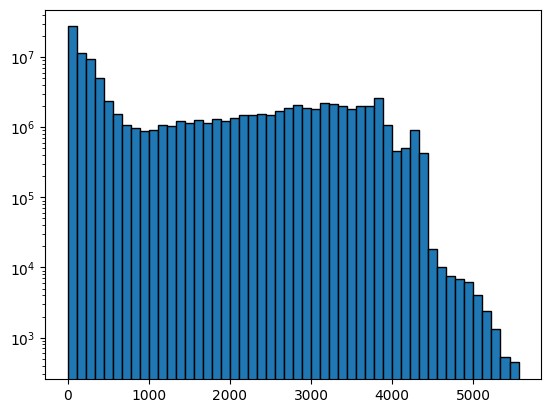

In [22]:
# Distribution of topographic depths in bathymetry dataset
df_topo['Depth_[m]'].hist(bins=50, edgecolor='black', log=True, grid=False)

<Axes: >

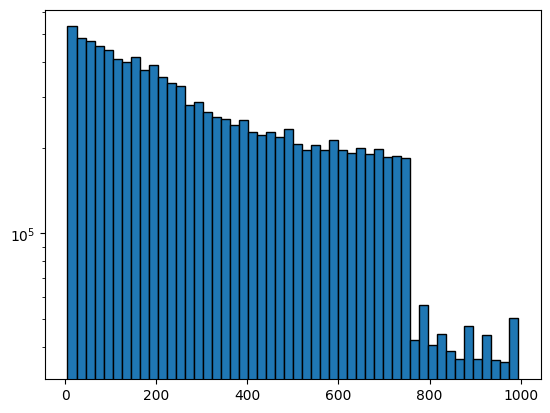

In [31]:
# Distribution of observed depths in profile dataset
df_ST['Depth_[m]'].hist(bins=50, edgecolor='black', log=True, grid=False)

<Axes: >

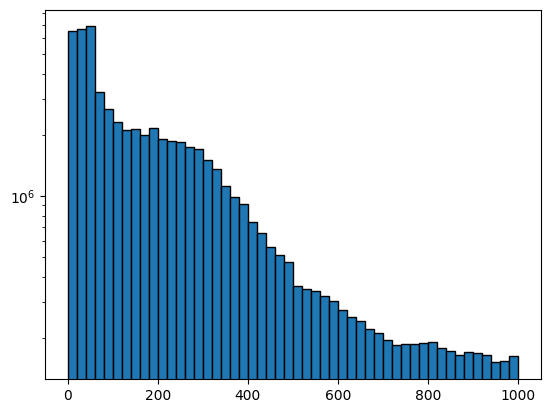

In [32]:
# Distribution of topographic depths in bathymetry dataset, cut to <1000m
df_topo[df_topo['Depth_[m]']<1000]['Depth_[m]'].hist(bins=50, edgecolor='black', log=True, grid=False)

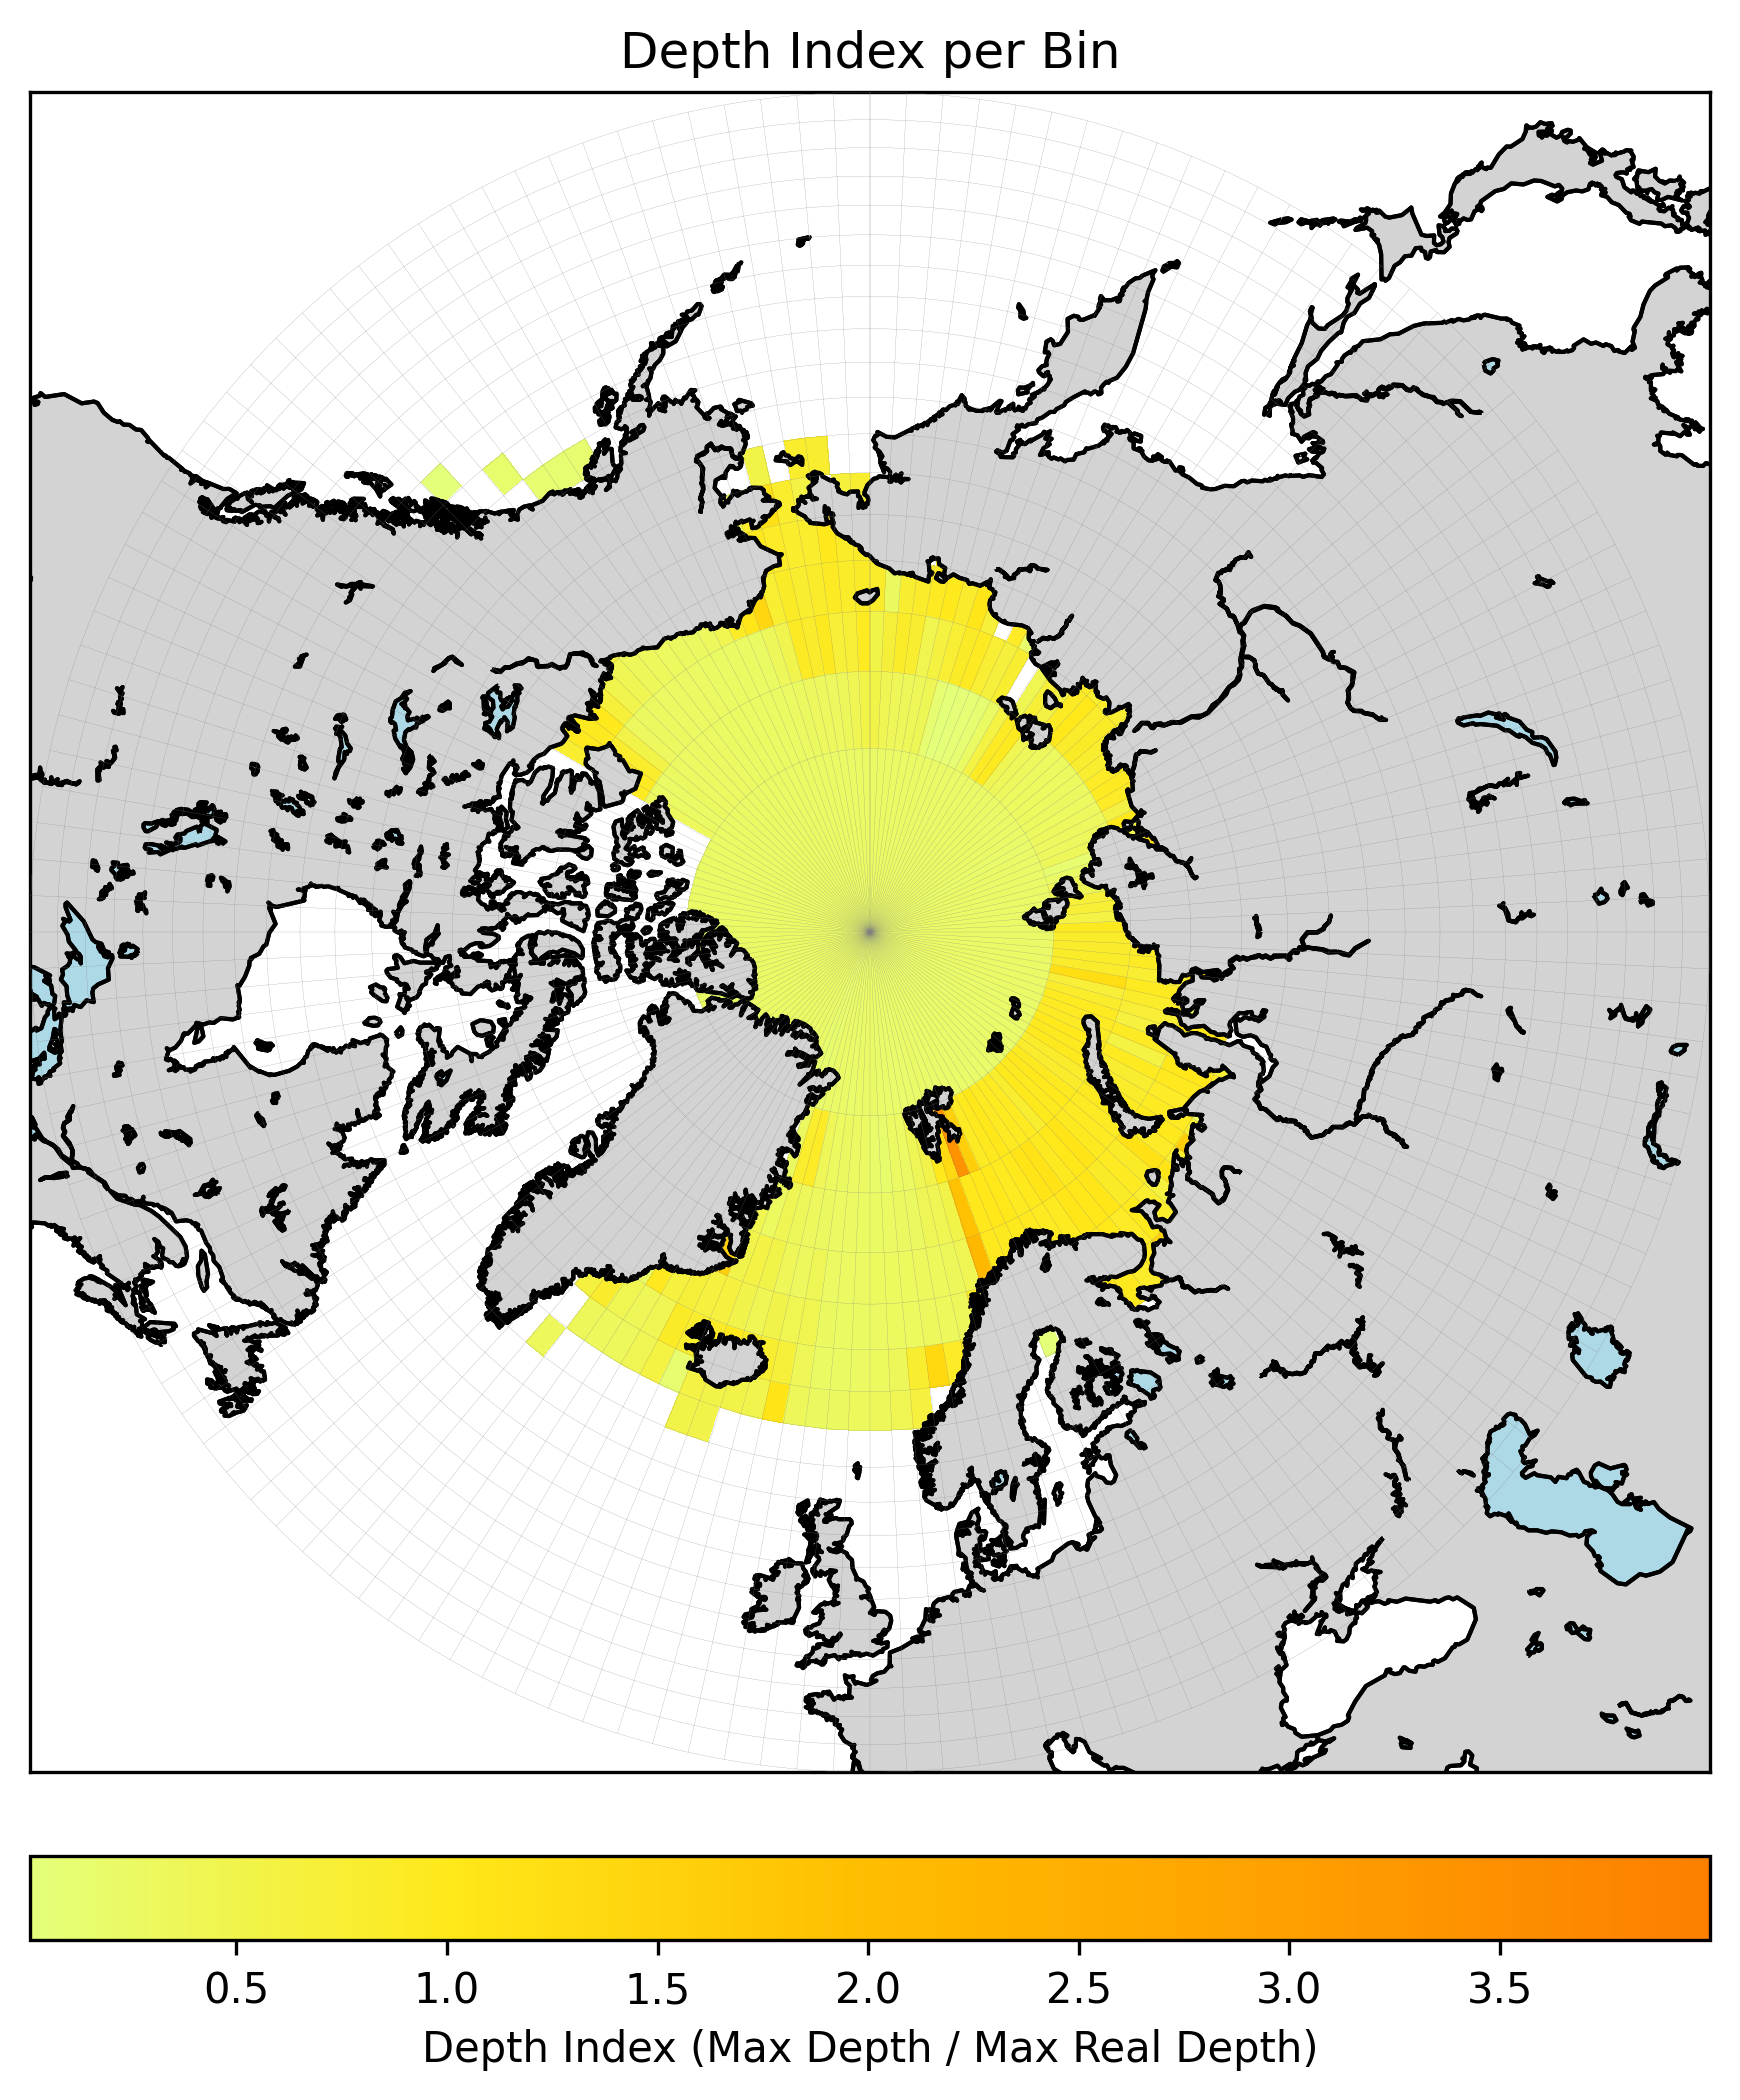

bin max=3.9983815280662944


In [36]:
plot_depthindex(df_ST, df_topo, n_lon_bins=144, n_lat_bins=18)